In [ ]:
!pip install gymnasium
!pip install "gymnasium[toy-text]"


# Taxi

In [1]:
import random
import gymnasium as gym
import numpy as np

In [2]:
env = gym.make('Taxi-v3')

alpha = 0.9
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.9995
min_epsilon = 0.01
num_epsodes = 10000
max_steps = 100

q_table = np.zeros((env.observation_space.n, env.action_space.n))

In [ ]:
print(env.observation_space.n, env.action_space.n)

500 6


In [3]:
def choose_action(state):
  if random.uniform(0, 1) < epsilon:
    return env.action_space.sample()
  else:
    return np.argmax(q_table[state, :])

In [4]:
for episode in range(num_epsodes):
  state, _ = env.reset()
  done = False
  best_reward = -np.inf

  for step in range(max_steps):
    action = choose_action(state)
    new_state, reward, done, truncated, info = env.step(action)

    if reward > best_reward:
      best_reward = reward

    old_value = q_table[state, action]
    next_max = np.max(q_table[new_state, :])

    new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
    q_table[state, action] = new_value

    state = new_state

    if done or truncated:
      break

  epsilon = max(min_epsilon, epsilon * epsilon_decay)

  if episode % 1000 == 0:
    print(f"Episode {episode} -> best_reward={best_reward}")

Episode 0 -> best_reward=-1
Episode 1000 -> best_reward=20
Episode 2000 -> best_reward=20
Episode 3000 -> best_reward=20
Episode 4000 -> best_reward=20
Episode 5000 -> best_reward=20
Episode 6000 -> best_reward=20
Episode 7000 -> best_reward=20
Episode 8000 -> best_reward=20
Episode 9000 -> best_reward=20


In [ ]:
env = gym.make('Taxi-v3', render_mode='human')

for episode in range(5):
  state, _ = env.reset()
  done = False

  print(f"Episode {episode}")

  for step in range(max_steps):
    env.render()
    action = np.argmax(q_table[state, :])

    new_state, reward, done, truncated, info = env.step(action)
    state = new_state

    if done or truncated:
      env.render()
      print(f"Finished episode {episode} with reward {reward}")
      break

Episode 0
Finished episode 0 with reward 20
Episode 1
Finished episode 1 with reward 20
Episode 2
Finished episode 2 with reward 20
Episode 3
Finished episode 3 with reward 20
Episode 4
Finished episode 4 with reward 20


: 

# Pole

In [ ]:
!pip install stable_baselines3

In [2]:
import gymnasium as gym
from stable_baselines3 import DQN
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

states = env.observation_space.shape[0]
actions = env.action_space.n

print(f"States: {states}, actions: {actions}")

States: 4, actions: 2


In [4]:
model = DQN("MlpPolicy", env, learning_rate=0.001, verbose=0)

model.learn(total_timesteps=50000, progress_bar=True)

Output()

In [5]:
def evaluate_model(model, env, num_episodes=10):
    """Runs multiple episodes and computes the mean episode reward."""
    episode_rewards = []

    for _ in range(num_episodes):
        obs, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
          action, _ = model.predict(obs)  # Choose best action
          obs, reward, done, truncated, info = env.step(action)  # Take action
          total_reward += reward  # Accumulate reward

        episode_rewards.append(total_reward)  # Store total reward

    mean_reward = np.mean(episode_rewards)  # Compute mean episode reward
    print(f"Mean Episode Reward over {num_episodes} episodes: {mean_reward}")
    return mean_reward, episode_rewards

# Run evaluation after training
mean_reward, reward_history = evaluate_model(model, env, num_episodes=10)

Mean Episode Reward over 10 episodes: 84.3


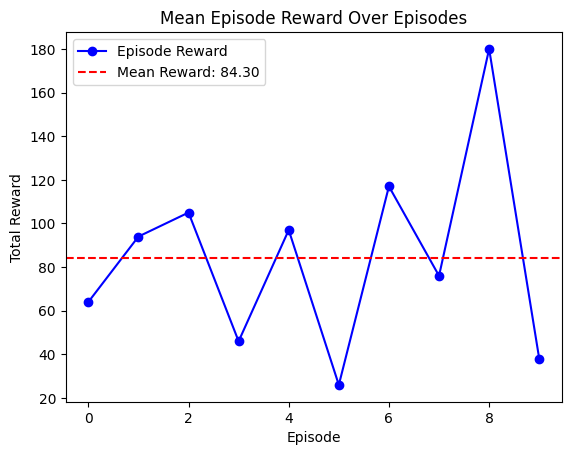

In [6]:
episodes = range(len(reward_history))

plt.plot(episodes, reward_history, marker='o', linestyle='-', color='b', label="Episode Reward")
plt.axhline(y=mean_reward, color='r', linestyle='--', label=f"Mean Reward: {mean_reward:.2f}")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Mean Episode Reward Over Episodes")
plt.legend()
plt.show()

In [10]:
# 6️⃣ Test & Render the Trained Agent
env = gym.make("CartPole-v1", render_mode="human")

for episode in range(5):
    obs, _ = env.reset()
    done = False
    total_reward = 0

    print(f"Episode {episode}")

    for i in range(1000):
        action, _ = model.predict(obs)
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward
        env.render()  # Show agent in action
        
        if done or truncated:
            print(f"Finished episode {episode} with reward {total_reward} and steps {i+1}")
            break

env.close()

Episode 0
Finished episode 0 with reward 77.0 and steps 77
Episode 1
Finished episode 1 with reward 161.0 and steps 161
Episode 2
Finished episode 2 with reward 55.0 and steps 55
Episode 3
Finished episode 3 with reward 97.0 and steps 97
Episode 4
Finished episode 4 with reward 104.0 and steps 104
